In [18]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [19]:
# ============================================================
# LOAD SAVED DATA
# ============================================================

data = pd.read_csv(
    "results/price_data_v1.csv",
    index_col=0,
    parse_dates=True
)

benchmark = pd.read_csv(
    "results/nifty50_data.csv",
    index_col=0,
    parse_dates=True
).squeeze()


data = data.sort_index()
benchmark = benchmark.sort_index()

print(data.shape)
data.head()

(1607, 48)


,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,BAJFINANCE.NS,BEL.NS,BHARTIARTL.NS,CIPLA.NS,...,SHRIRAMFIN.NS,SUNPHARMA.NS,TATACONSUM.NS,TATASTEEL.NS,TCS.NS,TECHM.NS,TITAN.NS,TRENT.NS,ULTRACEMCO.NS,WIPRO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-01,205.794525,361.062561,1403.106934,1690.746338,745.586914,2599.727783,413.532196,29.713722,433.316498,449.420258,...,201.816833,406.074036,306.714355,38.457085,1841.149292,602.617493,1132.704956,526.402710,3942.765625,113.709183
2020-01-02,209.111359,366.321014,1470.294067,1688.342407,753.802612,2575.711670,414.973724,30.603800,435.132721,447.153778,...,204.996552,406.681732,306.240814,39.862995,1832.697754,605.740845,1133.538574,538.030945,4117.158691,113.984634
2020-01-03,206.240067,365.699554,1461.883301,1651.334717,739.860840,2535.314453,409.833008,29.951080,435.037109,443.801361,...,204.899414,415.704620,301.363312,39.768440,1869.222168,612.897095,1117.942017,532.614319,4092.329102,115.269989
2020-01-06,197.576599,363.500580,1438.667969,1609.613159,720.242676,2506.924316,390.604340,28.764307,429.827362,440.779388,...,197.338669,411.356781,295.586090,38.909275,1869.051880,609.180664,1136.481201,526.700928,4032.095703,115.751999
2020-01-07,202.032074,367.898529,1454.603760,1625.877197,722.732300,2507.171875,391.674469,28.586292,425.477966,442.526489,...,198.601746,417.387543,298.237915,39.143593,1873.639404,614.478577,1137.805542,529.682434,4114.540039,117.152138


In [20]:
momentum = (
    data
    .pct_change(63)
    .shift(1)
)

ema50 = (
    data
    .ewm(
        span=50,
        adjust=False
    )
    .mean()
    .shift(1)
)

ema_slope = ema50.pct_change(10)

price_yesterday = data.shift(1)


nifty_ret = benchmark.squeeze().pct_change()

# 20-day volatility

market_vol = (
    nifty_ret
    .rolling(20)
    .std()
)

# Long-term volatility

long_vol = (
    market_vol
    .rolling(100)
    .mean()
)

# Volatility Trend Signal

vol_ratio = (
    market_vol
    /
    long_vol
)

In [21]:
low_ratio = 0.8
high_ratio = 1.2
extreme_ratio = 1.5

In [22]:
def get_exposure(vol_ratio):

    if pd.isna(vol_ratio):
        return 1.0

    elif vol_ratio > extreme_ratio:
        return 0.0

    elif vol_ratio > high_ratio:
        return 0.4

    elif vol_ratio > low_ratio:
        return 0.8

    else:
        return 1.0

In [23]:
rebalance_dates = momentum.index[63::63]

In [24]:
portfolio_returns = []

dates = []

exposure_history = []

for i in range(len(rebalance_dates)-1):

    current_date = rebalance_dates[i]
    next_date = rebalance_dates[i+1]

    mom = momentum.loc[current_date]

    trend_filter = (
        (price_yesterday.loc[current_date] >
         ema50.loc[current_date])
        &
        (ema_slope.loc[current_date] > 0)
    )

    eligible = mom[trend_filter]

    selected = eligible.nlargest(5).index

    current_ratio = vol_ratio.loc[current_date]

    exposure = get_exposure(
    current_ratio
    )

    

    exposure_history.append(
        exposure
    )

    holding_returns = (
        data.loc[next_date, selected]
        /
        data.loc[current_date, selected]
        - 1
    )

    portfolio_return = (
        holding_returns.mean()
        * exposure
    )

    portfolio_returns.append(
        portfolio_return
    )

    dates.append(next_date)

In [25]:
portfolio_returns = pd.Series(
    portfolio_returns,
    index=dates
)

portfolio_value = (
    1 + portfolio_returns
).cumprod()

In [26]:
benchmark_returns = (
    benchmark.squeeze()
    .pct_change()
)

benchmark_returns = (
    benchmark_returns
    .loc[portfolio_value.index]
)

benchmark_value = (
    1 + benchmark_returns
).cumprod()

In [27]:
years = (
    portfolio_value.index[-1]
    -
    portfolio_value.index[0]
).days / 365.25

total_return = (
    portfolio_value.iloc[-1] - 1
)

cagr = (
    portfolio_value.iloc[-1]
    **
    (1 / years)
    - 1
)

sharpe = (
    portfolio_returns.mean()
    /
    portfolio_returns.std()
    *
    np.sqrt(252 / 63)
)

drawdown = (
    portfolio_value
    /
    portfolio_value.cummax()
    - 1
)

max_dd = drawdown.min()

print(f"Total Return: {total_return:.2%}")
print(f"CAGR: {cagr:.2%}")
print(f"Sharpe: {sharpe:.2f}")
print(f"Max Drawdown: {max_dd:.2%}")

Total Return: 472.97%
CAGR: 34.78%
Sharpe: 1.89
Max Drawdown: -4.00%


In [28]:
exposure_series = pd.Series(
    exposure_history,
    index=rebalance_dates[:-1]
)

print(
    "Average Exposure:",
    f"{exposure_series.mean():.2%}"
)

print(
    "Time In Cash:",
    f"{(exposure_series == 0).mean():.2%}"
)

print(
    "Time Fully Invested:",
    f"{(exposure_series == 1).mean():.2%}"
)

Average Exposure: 79.17%
Time In Cash: 4.17%
Time Fully Invested: 29.17%


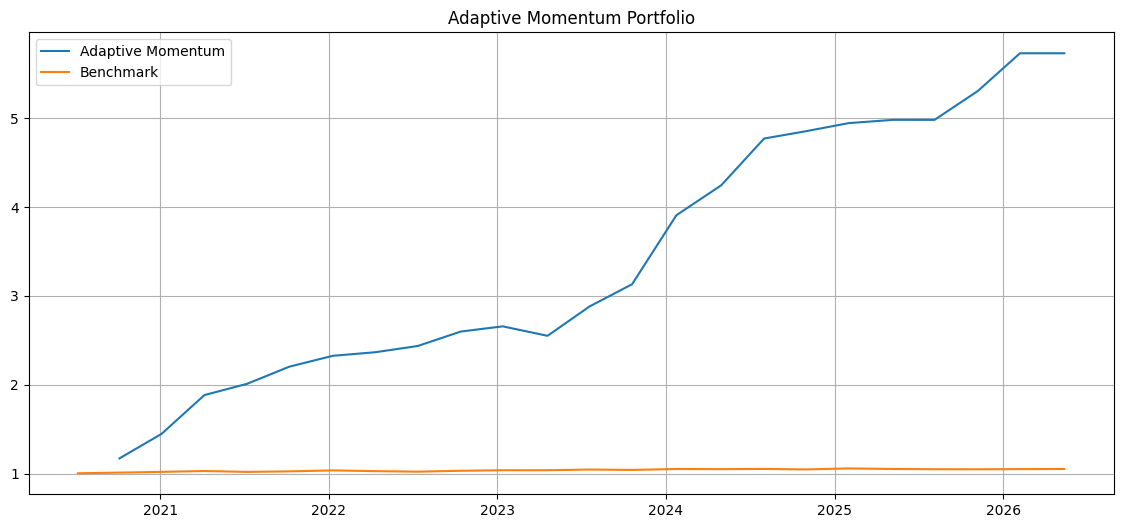

In [29]:
plt.figure(figsize=(14,6))

plt.plot(
    portfolio_value,
    label="Adaptive Momentum"
)

plt.plot(
    benchmark_value,
    label="Benchmark"
)

plt.title(
    "Adaptive Momentum Portfolio"
)

plt.legend()

plt.grid(True)

plt.show()

In [30]:
exposure_series.value_counts().sort_index()

0.0     1
0.4     2
0.8    14
1.0     7
Name: count, dtype: int64

In [31]:


# ============================================
# ORIGINAL MOMENTUM PORTFOLIO
# ============================================

original_returns = []
original_dates = []

for i in range(len(rebalance_dates)-1):

    current_date = rebalance_dates[i]
    next_date = rebalance_dates[i+1]

    mom = momentum.loc[current_date]

    trend_filter = (
        (price_yesterday.loc[current_date] >
         ema50.loc[current_date])
        &
        (ema_slope.loc[current_date] > 0)
    )

    eligible = mom[trend_filter]

    selected = eligible.nlargest(5)

    if len(selected) == 0:
        continue

    period_returns = (
        data.loc[next_date, selected.index]
        /
        data.loc[current_date, selected.index]
        - 1
    )

    original_returns.append(
        period_returns.mean()
    )

    original_dates.append(
        next_date
    )

original_returns = pd.Series(
    original_returns,
    index=original_dates
)

original_value = (
    1 + original_returns
).cumprod()

# ============================================
# SAVE COMPARISON TABLE
# ============================================

comparison = pd.DataFrame({

    "Original_Momentum":
        original_value,

    "Adaptive_Momentum":
        portfolio_value.reindex(
            original_value.index
        ),

    "Benchmark":
        benchmark_value.reindex(
            original_value.index
        )

})

comparison.to_csv(
    "results/adaptive_overlay_comparison.csv"
)

# ============================================
# SAVE EXPOSURE HISTORY
# ============================================

exposure_series.to_csv(
    "results/exposure_history.csv"
)

# ============================================
# SAVE EXPOSURE DISTRIBUTION
# ============================================

exposure_stats = (
    exposure_series
    .value_counts()
    .sort_index()
)

exposure_stats.to_csv(
    "results/exposure_distribution.csv"
)

# ============================================
# INTERACTIVE EQUITY CURVE
# ============================================

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=comparison.index,
        y=comparison["Original_Momentum"],
        name="Original Momentum"
    )
)

fig.add_trace(
    go.Scatter(
        x=comparison.index,
        y=comparison["Adaptive_Momentum"],
        name="Adaptive Overlay"
    )
)

fig.add_trace(
    go.Scatter(
        x=comparison.index,
        y=comparison["Benchmark"],
        name="Benchmark"
    )
)

fig.update_layout(
    title="Original Momentum vs Adaptive Overlay vs Benchmark",
    xaxis_title="Date",
    yaxis_title="Portfolio Value",
    hovermode="x unified"
)

fig.write_html(
    "plots/adaptive_overlay_comparison.html"
)

fig.show()

print("Saved:")
print("- results/adaptive_overlay_comparison.csv")
print("- results/exposure_history.csv")
print("- results/exposure_distribution.csv")
print("- plots/adaptive_overlay_comparison.html")

Saved:
- results/adaptive_overlay_comparison.csv
- results/exposure_history.csv
- results/exposure_distribution.csv
- plots/adaptive_overlay_comparison.html
